# Customer Retention and Revenue Prioritization

## tl;dr

- Repeat orders generated **85.8%** of observed revenue.
- Weighted retention was **23.4% at M1** and **22.1% at M6**.
- The current high-value risk pool contains **135 customers** with **£468,149** in trailing historical revenue.
- In the historical backtest, High-Value At Risk customers repurchased at **67.6%**, versus **34.1%** for High-Value Lapsed customers.
- Recommendation: prioritize High-Value At Risk customers first; treat lapsed customers as a separate, lower-confidence reactivation group.

## Context & Methods

**Business question:** Which customers and markets should be prioritized to retain repeat revenue?

The analysis follows four simple steps: measure repeat-revenue health, calculate cohort retention, backtest behavioral segments, and identify actionable customer, market, and product priorities.

### Key Assumptions

- December 2011 is incomplete and excluded from performance calculations.
- Cancelled invoices, returns, non-positive prices, and rows without Customer ID are excluded.
- RFM segments describe observed behavior; they do not prove why a customer stopped purchasing.
- Historical revenue in a risk segment is not a forecast or guaranteed revenue uplift.

In [1]:
from pathlib import Path
import sys, sqlite3

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / '.python-packages'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

DB_PATH = PROJECT_ROOT / 'data' / 'processed' / 'retention_analysis.sqlite'
CHART_DIR = PROJECT_ROOT / 'outputs' / 'charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)
connection = sqlite3.connect(DB_PATH)
plt.style.use('seaborn-v0_8-whitegrid')

## Data

### 1. Check the source and cleaning flow

In [2]:
quality_sql = """
SELECT quality_check, rows, share_of_raw_rows
FROM data_quality_summary
ORDER BY check_order
"""
quality = pd.read_sql_query(quality_sql, connection)
display(quality)

,quality_check,rows,share_of_raw_rows
0,Raw rows,1067371,1.000000
1,Exact duplicate rows,34335,0.032168
2,Rows without Customer ID,243007,0.227669
3,Cancelled invoice rows,19494,0.018264
4,Rows with non-positive quantity,22950,0.021501
5,Rows with non-positive price,6207,0.005815
6,Rows with invalid invoice date,0,0.000000
7,Rows in incomplete Dec-2011 period,25526,0.023915


In [3]:
cleaning_sql = """
SELECT stage, rows, removed_from_previous, retained_share_of_raw
FROM cleaning_flow
"""
cleaning = pd.read_sql_query(cleaning_sql, connection)
display(cleaning)

,stage,rows,removed_from_previous,retained_share_of_raw
0,Raw source,1067371,NaN,1.000000
1,After exact deduplication,1033036,34335.0,0.967832
2,After requiring Customer ID,797885,235151.0,0.747524
3,After excluding cancellations,779495,18390.0,0.730294
4,After positive quantity and price,779425,70.0,0.730229
5,Analysis-ready clean rows,779425,0.0,0.730229


## Results

### 2. How dependent is revenue on repeat purchasing?

In [4]:
headline_sql = """
SELECT
    COUNT(DISTINCT customer_id) AS customers,
    COUNT(*) AS orders,
    SUM(order_revenue) AS revenue,
    SUM(CASE WHEN customer_order_number > 1 THEN order_revenue ELSE 0 END) AS repeat_revenue,
    1.0 * SUM(CASE WHEN customer_order_number > 1 THEN order_revenue ELSE 0 END)
        / SUM(order_revenue) AS repeat_revenue_share
FROM fact_orders_enriched
"""
headline = pd.read_sql_query(headline_sql, connection)
display(headline)

,customers,orders,revenue,repeat_revenue,repeat_revenue_share
0,5850,36255,1.685760e+07,14459189.44,0.857725


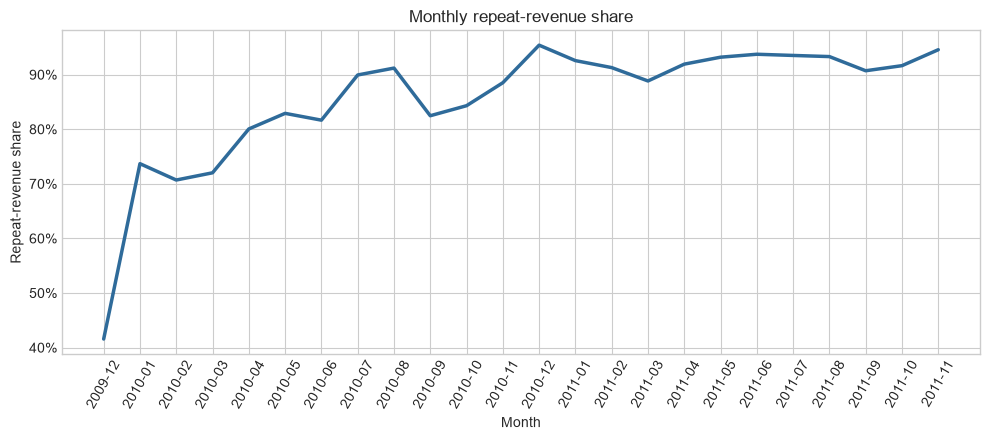

In [5]:
monthly = pd.read_sql_query(
    'SELECT * FROM monthly_customer_metrics ORDER BY activity_month', connection
)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(monthly['activity_month'], monthly['repeat_revenue_share'], color='#2F6B9A', linewidth=2.5)
ax.set_title('Monthly repeat-revenue share')
ax.set_xlabel('Month')
ax.set_ylabel('Repeat-revenue share')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.tick_params(axis='x', rotation=60)
fig.tight_layout()
fig.savefig(CHART_DIR / 'monthly_repeat_revenue.png', dpi=160, bbox_inches='tight')
plt.show()

### 3. Where does retention decline across acquisition cohorts?

In [6]:
cohort_sql = """
SELECT cohort_month, month_number, cohort_size, retained_customers, retention_rate
FROM cohort_retention
WHERE month_number <= 12
ORDER BY cohort_month, month_number
"""
cohort = pd.read_sql_query(cohort_sql, connection)
cohort_matrix = cohort.pivot(index='cohort_month', columns='month_number', values='retention_rate')
display(cohort_matrix.round(3).tail(12))

month_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12,1.0,0.092,0.053,0.092,0.118,0.066,0.053,0.092,0.053,0.026,0.092,0.197,NaN
2011-01,1.0,0.169,0.211,0.197,0.211,0.155,0.155,0.127,0.113,0.211,0.254,NaN,NaN
2011-02,1.0,0.161,0.153,0.185,0.218,0.153,0.153,0.145,0.145,0.177,NaN,NaN,NaN
2011-03,1.0,0.184,0.218,0.201,0.223,0.151,0.207,0.201,0.240,NaN,NaN,NaN,NaN
2011-04,1.0,0.255,0.198,0.198,0.179,0.236,0.179,0.255,NaN,NaN,NaN,NaN,NaN
2011-05,1.0,0.234,0.243,0.162,0.216,0.207,0.261,NaN,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.231,0.213,0.269,0.204,0.287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.216,0.304,0.275,0.343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.274,0.311,0.264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


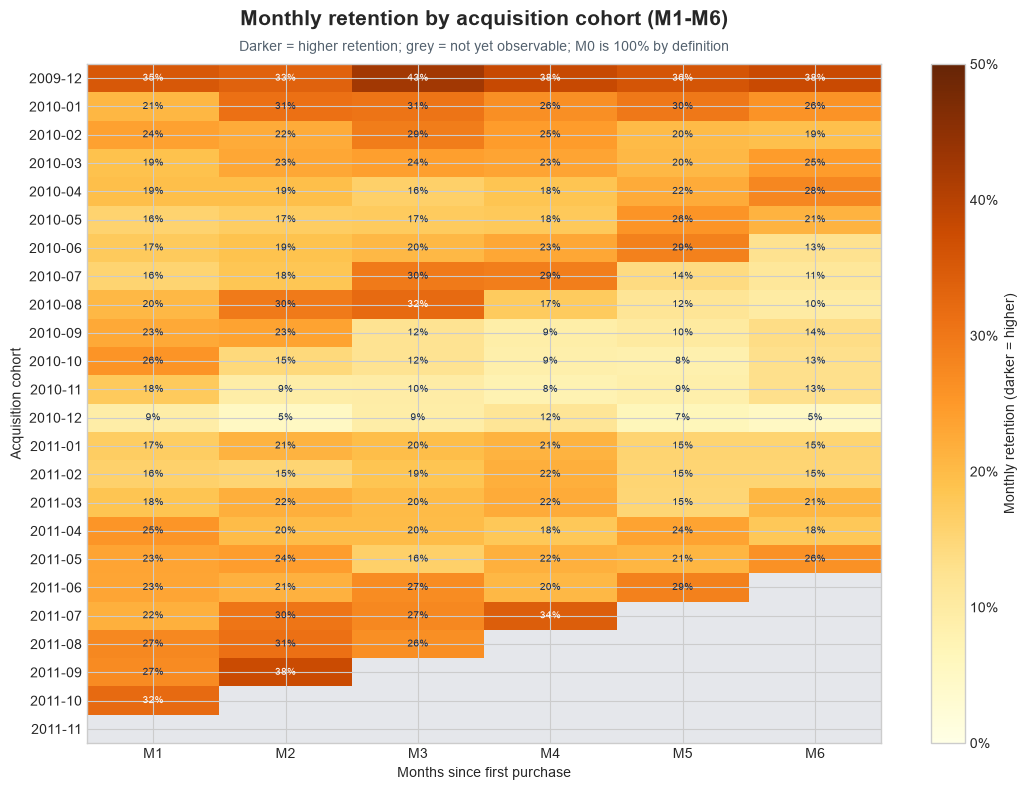

In [7]:
cohort_heatmap = cohort_matrix.loc[:, (cohort_matrix.columns >= 1) & (cohort_matrix.columns <= 6)]
fig, ax = plt.subplots(figsize=(11, 8))
palette = plt.get_cmap('YlOrBr').copy()
palette.set_bad('#E5E7EB')
values = np.ma.masked_invalid(cohort_heatmap.to_numpy(dtype=float))
image = ax.imshow(values, aspect='auto', cmap=palette, vmin=0, vmax=0.5)
ax.set_title('Monthly retention by acquisition cohort (M1-M6)', fontsize=15, weight='bold', pad=28)
ax.text(0.5, 1.015, 'Darker = higher retention; grey = not yet observable; M0 is 100% by definition',
        transform=ax.transAxes, ha='center', va='bottom', color='#52606D', fontsize=10)
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Acquisition cohort')
ax.set_xticks(range(len(cohort_heatmap.columns)))
ax.set_xticklabels([f'M{month}' for month in cohort_heatmap.columns])
ax.set_yticks(range(len(cohort_heatmap.index)))
ax.set_yticklabels(cohort_heatmap.index)
for row_index in range(cohort_heatmap.shape[0]):
    for column_index in range(cohort_heatmap.shape[1]):
        value = cohort_heatmap.iat[row_index, column_index]
        if pd.notna(value):
            text_color = 'white' if value >= 0.32 else '#172B4D'
            ax.text(column_index, row_index, f'{value:.0%}', ha='center', va='center',
                    color=text_color, fontsize=7)
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label('Monthly retention (darker = higher)')
colorbar.ax.yaxis.set_major_formatter(PercentFormatter(1))
fig.tight_layout()
fig.savefig(CHART_DIR / 'cohort_retention_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()

### 4. Which behavioral segments were most likely to repurchase?

In [8]:
backtest_sql = """
SELECT
    rfm_segment, customers, next_12m_repeat_rate, next_12m_revenue, avg_next_12m_revenue
FROM rfm_backtest_summary
ORDER BY next_12m_repeat_rate DESC
"""
backtest = pd.read_sql_query(backtest_sql, connection)
display(backtest)

,rfm_segment,customers,next_12m_repeat_rate,next_12m_revenue,avg_next_12m_revenue
0,Loyal Active,1215,0.912757,5459676.171,4493.560635
1,Repeat Active,1025,0.712195,613748.800,598.779317
2,High-Value At Risk,108,0.675926,213568.830,1977.489167
3,New / One-time Recent,637,0.483516,232380.871,364.805135
4,Occasional At Risk,494,0.457490,161434.671,326.790832
5,High-Value Lapsed,44,0.340909,14034.470,318.965227
6,Hibernating,743,0.339166,177936.170,239.483405


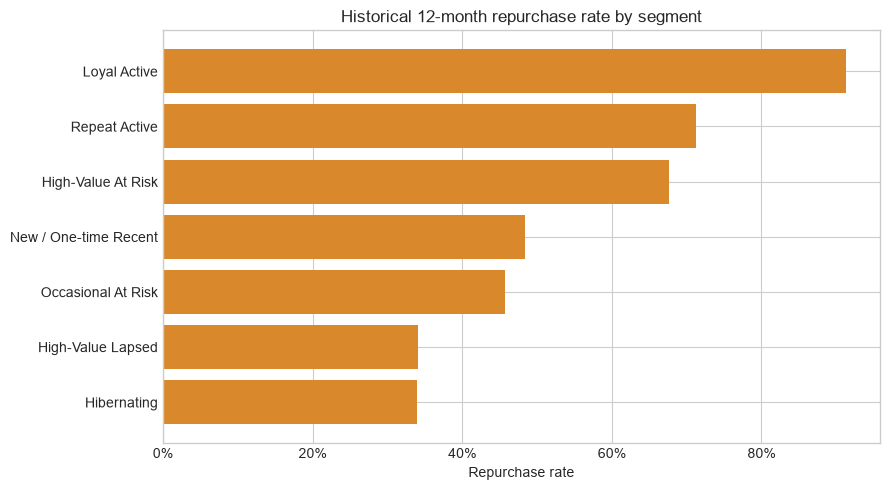

In [9]:
plot_data = backtest.sort_values('next_12m_repeat_rate')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_data['rfm_segment'], plot_data['next_12m_repeat_rate'], color='#D9892B')
ax.set_title('Historical 12-month repurchase rate by segment')
ax.set_xlabel('Repurchase rate')
ax.xaxis.set_major_formatter(PercentFormatter(1))
fig.tight_layout()
fig.savefig(CHART_DIR / 'segment_backtest.png', dpi=160, bbox_inches='tight')
plt.show()

### 5. Which current customers and markets should CRM prioritize?

In [10]:
segment_sql = """
SELECT
    c.rfm_segment, c.customers, c.trailing_12m_revenue, c.avg_recency_days,
    b.next_12m_repeat_rate
FROM rfm_current_summary AS c
LEFT JOIN rfm_backtest_summary AS b
    ON c.rfm_segment = b.rfm_segment
ORDER BY c.trailing_12m_revenue DESC
"""
segments = pd.read_sql_query(segment_sql, connection)
display(segments)

,rfm_segment,customers,trailing_12m_revenue,avg_recency_days,next_12m_repeat_rate
0,Loyal Active,1186,6388529.340,23.595278,0.912757
1,Repeat Active,996,739676.932,32.833333,0.712195
2,Hibernating,804,291477.790,265.937811,0.339166
3,Occasional At Risk,518,255990.810,134.905405,0.457490
4,High-Value At Risk,92,248139.080,124.152174,0.675926
5,New / One-time Recent,658,226194.461,40.066869,0.483516
6,High-Value Lapsed,43,220010.041,254.162791,0.340909


In [11]:
country_sql = """
SELECT country, customers, target_customers, target_customer_share, target_historical_revenue
FROM country_priority
WHERE customers >= 20
ORDER BY target_historical_revenue DESC
"""
countries = pd.read_sql_query(country_sql, connection)
display(countries)

,country,customers,target_customers,target_customer_share,target_historical_revenue
0,United Kingdom,3886,109,0.028049,395894.791
1,Germany,93,5,0.053763,17334.630
2,France,86,2,0.023256,6088.670
3,Switzerland,21,2,0.095238,5636.740
4,Belgium,24,2,0.083333,3501.230
5,Spain,27,0,0.000000,0.000


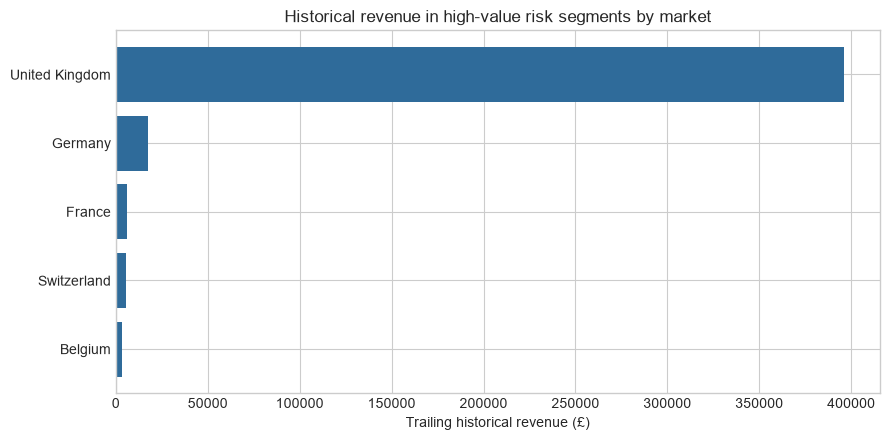

In [12]:
country_plot = countries.loc[countries['target_customers'] > 0].sort_values('target_historical_revenue')
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(country_plot['country'], country_plot['target_historical_revenue'], color='#2F6B9A')
ax.set_title('Historical revenue in high-value risk segments by market')
ax.set_xlabel('Trailing historical revenue (£)')
fig.tight_layout()
fig.savefig(CHART_DIR / 'country_priority.png', dpi=160, bbox_inches='tight')
plt.show()

### 6. Which products are familiar to the target customers?

In [13]:
product_sql = """
SELECT stock_code, product_description, target_customers, historical_revenue
FROM target_product_affinity
WHERE target_customers >= 10
ORDER BY target_customers DESC, historical_revenue DESC
LIMIT 15
"""
products = pd.read_sql_query(product_sql, connection)
display(products)

,stock_code,product_description,target_customers,historical_revenue
0,22423,REGENCY CAKESTAND 3 TIER,46,4426.15
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,41,13096.40
2,47566,PARTY BUNTING,39,5915.60
3,22720,SET OF 3 CAKE TINS PANTRY DESIGN,33,1628.20
4,21212,PACK OF 72 RETROSPOT CAKE CASES,31,2137.58
5,22960,JAM MAKING SET WITH JARS,31,1512.75
6,22457,NATURAL SLATE HEART CHALKBOARD,30,1368.70
7,21754,HOME BUILDING BLOCK WORD,29,978.70
8,20725,LUNCH BAG RED RETROSPOT,28,1731.40
9,23298,SPOTTY BUNTING,27,2057.60


## Takeaways

1. Repeat purchasing is economically important: it generated **85.8%** of observed revenue.
2. Retention remains near one quarter at M1/M3 and declines to **22.1%** at M6.
3. **High-Value At Risk** is the first CRM priority: the historical backtest shows a **67.6%** 12-month repurchase rate.
4. **High-Value Lapsed** needs a separate reactivation motion: its backtested repurchase rate was only **34.1%**.
5. The two target groups contain **135 customers** and **£468,149** in trailing historical revenue; this is an observed value base, not predicted uplift.
6. The United Kingdom contains **109 target customers** and **£395,895** of that historical revenue, so it is the only market with sufficient scale for a first pilot.

In [14]:
connection.close()